# Flow Matching: Inequality Constraints (Barrier Method)

Two examples:
1. Abstract optimization: Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$
2. Reaction equilibrium: Find equilibrium extent for $A + B \rightleftharpoons 2C$

**Authors:** Victor Alves and John R. Kitchin

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import os

# Force CPU for JAX (must be set before importing JAX)
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
import jax
import jax.numpy as jnp
from jax import jacobian, vmap
from scipy.optimize import minimize, minimize_scalar

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    cluster_stats,
    ConditionalFlowMatching
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## 1. Abstract Optimization with Barrier Method

**Problem:** Minimize $(x-2)^2 + (y-1)^2$ subject to $x + y \geq 1$

The barrier objective is:
$$f(x, y) = (x-2)^2 + (y-1)^2 - \mu \log(x + y - 1)$$

At the optimum, the gradient is zero: $\nabla f = 0$.

In [2]:
# Scipy solution
def f_ineq(X):
    x, y = X
    return (x - 2)**2 + (y - 1)**2

def c1(X):
    return X[0] + X[1] - 1

sol = minimize(f_ineq, [1, 1], constraints={'type': 'ineq', 'fun': c1})
print(f"Scipy solution: {sol.x}")

Scipy solution: [2.         0.99999999]


In [3]:
# Barrier objective
def barrier_objective(X, mu=1e-7):
    x, y = X
    obj = (x - 2)**2 + (y - 1)**2
    barrier = -mu * jnp.log(x + y - 1)
    return obj + barrier

# Sample feasible region
bounds = [[0, 3], [0, 3]]
inputs = generate_samples(bounds, n_samples=1024, method='uniform', seed=42)

# Filter to feasible
feasible = inputs[:, 0] + inputs[:, 1] > 1.01
inputs = inputs[feasible]

# Compute gradients
outputs = np.array(vmap(jacobian(barrier_objective))(inputs))

print(f"Feasible samples: {len(inputs)}")

Feasible samples: 950


In [4]:
# Train
fm_barrier = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=64, n_layers=3)
losses = fm_barrier.fit(inputs, outputs, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [5]:
# Sample by conditioning on gradient = 0
samples = fm_barrier.sample(c_values=[[0.0, 0.0]], n_samples=500)

x_opt = samples.mean(axis=0)
print(f"Flow Matching solution: x={x_opt[0]:.4f}, y={x_opt[1]:.4f}")
print(f"Expected: x=2.0, y=1.0")

Flow Matching solution: x=2.0043, y=1.0096
Expected: x=2.0, y=1.0


---

## 2. Reaction Equilibrium with Concentration Constraints

A physically motivated example: finding the equilibrium composition of a reversible reaction $A + B \rightleftharpoons 2C$ in a batch reactor.

Given initial concentrations $C_{A0} = C_{B0} = 1$ mol/L and $C_{C0} = 0$, the concentrations evolve with extent of reaction $\xi$:
- $C_A = 1 - \xi$
- $C_B = 1 - \xi$
- $C_C = 2\xi$

The equilibrium condition:
$$K_{eq} = \frac{C_C^2}{C_A \cdot C_B} = \frac{(2\xi)^2}{(1-\xi)^2}$$

**Root finding formulation:** Find $\xi$ where $f(\xi) = K_{eq}(1-\xi)^2 - 4\xi^2 = 0$

**Physical constraints:** Non-negative concentrations require $0 < \xi < 1$

**Flow Matching approach:** We sample $\xi$ only in the feasible region $(0, 1)$, train on $[\xi, f(\xi)]$, and condition on $f(\xi) = 0$ to find the root.

In [6]:
# Reaction equilibrium: A + B ⇌ 2C
Keq = 4.0  # Equilibrium constant

# Analytical solution
# Keq(1-ξ)² = 4ξ² → for Keq=4: (1-ξ)² = ξ² → 1-ξ = ±ξ
# Physical root: ξ = 0.5
xi_analytical = 0.5

print("Reaction Equilibrium: A + B ⇌ 2C")
print(f"Keq = {Keq}")
print(f"\nAnalytical solution: ξ = {xi_analytical}")
print(f"Equilibrium concentrations:")
print(f"  CA = CB = {1 - xi_analytical:.2f} mol/L")
print(f"  CC = {2 * xi_analytical:.2f} mol/L")

# Verify with scipy
def residual_fn(xi):
    return Keq * (1 - xi)**2 - 4 * xi**2

result_scipy_eq = minimize_scalar(lambda x: residual_fn(x)**2, bounds=(0.01, 0.99), method='bounded')
print(f"\nScipy verification: ξ = {result_scipy_eq.x:.6f}")

Reaction Equilibrium: A + B ⇌ 2C
Keq = 4.0

Analytical solution: ξ = 0.5
Equilibrium concentrations:
  CA = CB = 0.50 mol/L
  CC = 1.00 mol/L

Scipy verification: ξ = 0.500000


In [7]:
# Generate training data: sample ξ in feasible region
n_eq_samples = 2000
np.random.seed(42)
xi_samples = np.random.uniform(0.01, 0.99, n_eq_samples)

# Compute residual for each sample
residuals = np.array([residual_fn(xi) for xi in xi_samples])

# Build joint dataset: [ξ, f(ξ)]
x_data_eq = xi_samples.reshape(-1, 1)
c_data_eq = residuals.reshape(-1, 1)

print(f"Training data shape: x={x_data_eq.shape}, c={c_data_eq.shape}")
print(f"ξ range: [{xi_samples.min():.3f}, {xi_samples.max():.3f}]")
print(f"Residual range: [{residuals.min():.3f}, {residuals.max():.3f}]")
print(f"\nVerification: f(0.5) = {residual_fn(0.5):.6f} (should be 0)")

Training data shape: x=(2000, 1), c=(2000, 1)
ξ range: [0.013, 0.990]
Residual range: [-3.918, 3.895]

Verification: f(0.5) = 0.000000 (should be 0)


In [8]:
# Train Flow Matching: generate ξ conditioned on f(ξ)
fm_eq = ConditionalFlowMatching(x_dim=1, c_dim=1, hidden_dim=64, n_layers=3)
losses = fm_eq.fit(x_data_eq, c_data_eq, epochs=500, batch_size=64)

Training:   0%|          | 0/500 [00:00<?, ?it/s]

In [9]:
# Sample by conditioning on f(ξ) = 0 (ROOT FINDING)
xi_fm_samples = fm_eq.sample(c_values=[[0.0]], n_samples=1000, n_steps=100)

print("Flow Matching Solution (conditioning on f(ξ) = 0):")
print(f"  ξ = {xi_fm_samples.mean():.4f} ± {xi_fm_samples.std():.4f}")
print(f"  Analytical: ξ = {xi_analytical}")

# Verify equilibrium residual
residual_fm = residual_fn(xi_fm_samples.mean())
print(f"  Residual at mean: {residual_fm:.6f}")

Flow Matching Solution (conditioning on f(ξ) = 0):
  ξ = 0.4999 ± 0.0036
  Analytical: ξ = 0.5
  Residual at mean: 0.000919


In [10]:
# Summary comparison
print("Reaction Equilibrium Comparison: A + B ⇌ 2C")
print("=" * 60)
print(f"Equilibrium constant: Keq = {Keq}")
print()

print(f"{'Method':<20} {'ξ':<15} {'|Residual|':<15}")
print("-" * 50)

# Analytical
print(f"{'Analytical':<20} {xi_analytical:<15.6f} {abs(residual_fn(xi_analytical)):<15.6f}")

# Scipy
print(f"{'Scipy':<20} {result_scipy_eq.x:<15.6f} {abs(residual_fn(result_scipy_eq.x)):<15.6f}")

# Flow Matching
xi_fm_mean = xi_fm_samples.mean()
print(f"{'Flow Matching':<20} {xi_fm_mean:<15.6f} {abs(residual_fn(xi_fm_mean)):<15.6f}")

Reaction Equilibrium Comparison: A + B ⇌ 2C
Equilibrium constant: Keq = 4.0

Method               ξ               |Residual|     
--------------------------------------------------
Analytical           0.500000        0.000000       
Scipy                0.500000        0.000000       
Flow Matching        0.499885        0.000919       


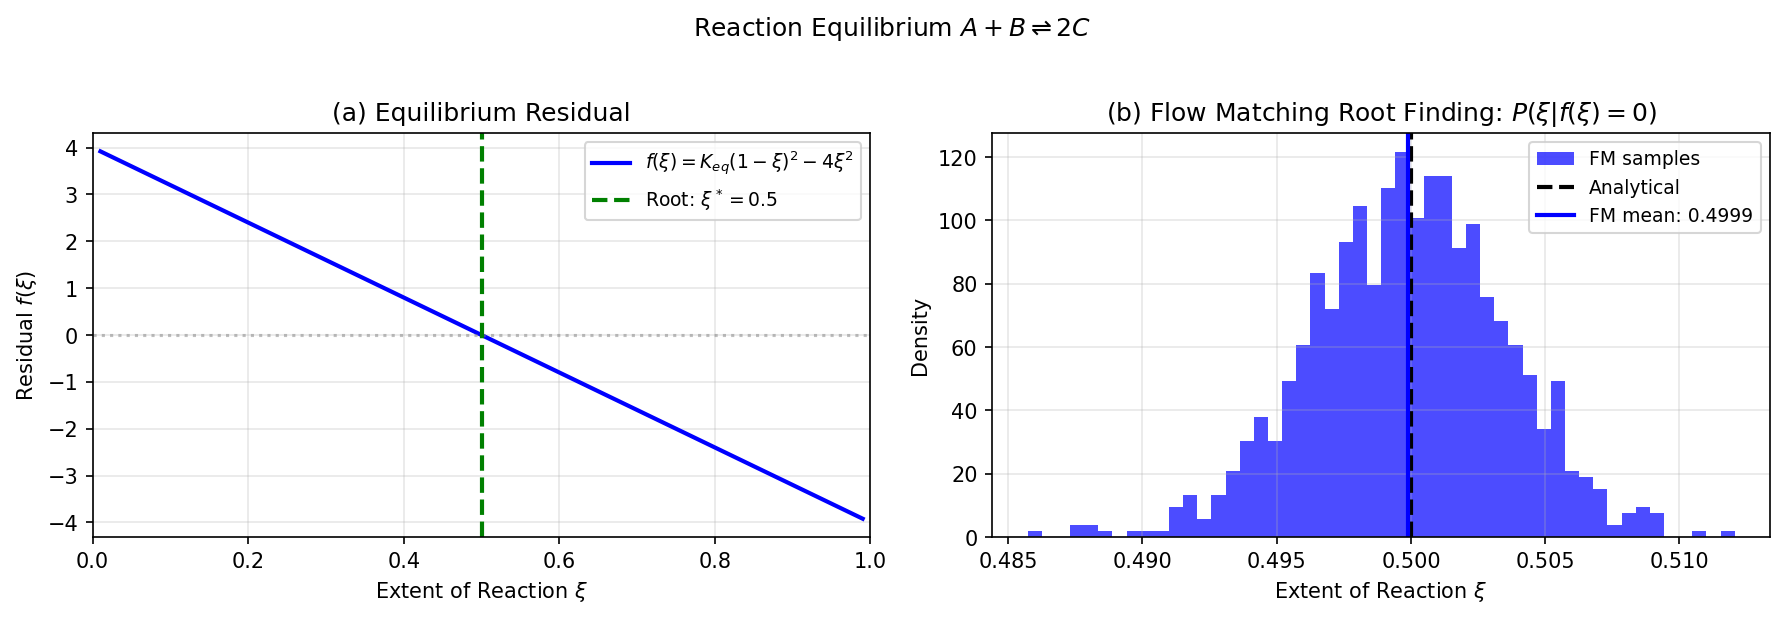

In [11]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Residual function
xi_plot = np.linspace(0.01, 0.99, 200)
f_plot = np.array([residual_fn(x) for x in xi_plot])

ax1.plot(xi_plot, f_plot, 'b-', lw=2, label='$f(\\xi) = K_{eq}(1-\\xi)^2 - 4\\xi^2$')
ax1.axhline(0, color='gray', ls=':', alpha=0.5)
ax1.axvline(xi_analytical, color='green', ls='--', lw=2, label=f'Root: $\\xi^*={xi_analytical}$')

ax1.set_xlabel('Extent of Reaction $\\xi$')
ax1.set_ylabel('Residual $f(\\xi)$')
ax1.set_title('(a) Equilibrium Residual')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# Right: Flow Matching histogram
ax2.hist(xi_fm_samples[:, 0], bins=50, alpha=0.7, color='blue', 
         label='FM samples', density=True)
ax2.axvline(xi_analytical, color='black', ls='--', lw=2, label='Analytical')
ax2.axvline(xi_fm_samples.mean(), color='blue', ls='-', lw=2, 
            label=f'FM mean: {xi_fm_samples.mean():.4f}')

ax2.set_xlabel('Extent of Reaction $\\xi$')
ax2.set_ylabel('Density')
ax2.set_title('(b) Flow Matching Root Finding: $P(\\xi | f(\\xi) = 0)$')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Reaction Equilibrium $A + B \\rightleftharpoons 2C$', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()